# Modelo ARIMA (AutoRegressive Integrated Moving Average) - clásico

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

# Cargar datos procesados
activos = ["eurusd", "gbpusd", "usdjpy", "btc", "eth"]
datos = {}

for activo in activos:
    df = pd.read_csv(f"../data/{activo}_processed.csv", index_col=0, parse_dates=True)
    datos[activo] = df
    print(f"{activo.upper()}: {len(df)} registros | Columnas: {list(df.columns)}")

EURUSD: 2145 registros | Columnas: ['Close', 'Retorno', 'Volatilidad_20d', 'Regimen']
GBPUSD: 2145 registros | Columnas: ['Close', 'Retorno', 'Volatilidad_20d', 'Regimen']
USDJPY: 2145 registros | Columnas: ['Close', 'Retorno', 'Volatilidad_20d', 'Regimen']
BTC: 3011 registros | Columnas: ['Close', 'Retorno', 'Volatilidad_20d', 'Regimen']
ETH: 3011 registros | Columnas: ['Close', 'Retorno', 'Volatilidad_20d', 'Regimen']


# Test de estacionaridad ADF

In [2]:
# Test de estacionariedad ADF sobre retornos
print("TEST DE ESTACIONARIEDAD (ADF) - Retornos diarios")
print("=" * 55)

for activo in activos:
    retornos = datos[activo]["Retorno"].dropna()
    resultados = adfuller(retornos)
    estacionaria = "ESTACIONARIA" if resultados[1] < 0.05 else "NO ESTACIONARIA"
    print(f"{activo.upper():8} | p-valor: {resultados[1]:.6f} | {estacionaria}")

TEST DE ESTACIONARIEDAD (ADF) - Retornos diarios
EURUSD   | p-valor: 0.000000 | ESTACIONARIA
GBPUSD   | p-valor: 0.000000 | ESTACIONARIA
USDJPY   | p-valor: 0.000000 | ESTACIONARIA
BTC      | p-valor: 0.000000 | ESTACIONARIA
ETH      | p-valor: 0.000000 | ESTACIONARIA


## Test de Estacionariedad (Augmented Dickey-Fuller)
+ **Rechazo de la hipótesis nula:** Los retornos diarios de los cinco activos presentan un p-valor de 0.0000. Esto permite rechazar categóricamente la existencia de una raíz unitaria (con un nivel de confianza superior al 99.99%) y confirmar que todas las series analizadas son estacionarias.

+ **Fijación del parámetro d=0:** En la metodología ARIMA, d representa el número de diferenciaciones requeridas para hacer una serie estacionaria. Al confirmarse la estacionariedad de los retornos (a diferencia de lo que ocurre con los precios brutos), se establece directamente d=0. Esto acota y optimiza el modelado, limitando la búsqueda de hiperparámetros a los términos autorregresivos (p) y de media móvil (q).

+ **Coherencia teórica:** La estacionariedad confirmada se alinea perfectamente con la Hipótesis de Eficiencia del Mercado en su forma débil, evidenciando que los retornos financieros se comportan como ruido blanco y carecen de patrones predecibles a largo plazo.

# ARIMA sobre EUR/USD

In [3]:
from itertools import product

# Selección de parámetros ARIMA por AIC sobre EUR/USD
print("Buscando mejores parámetros ARIMA para EURUSD...")
print("=" * 50)

retornos_eurusd = datos["eurusd"]["Retorno"].dropna()

# Grid search p y q entre 0 y 3, d fijo en 0 (retornos ya estacionarios)
mejor_aic = np.inf
mejor_orden = None

for p, q in product(range(4), range (4)):
    try:
        modelo = ARIMA(retornos_eurusd, order=(p, 0, q))
        resultado = modelo.fit()
        if resultado.aic < mejor_aic:
            mejor_aic = resultado.aic
            mejor_orden = (p, 0, q)
    except:
        continue

print(f"Mejor orden: {mejor_orden}")
print(f"Mejor AIC: {mejor_aic:.4f}")

Buscando mejores parámetros ARIMA para EURUSD...
Mejor orden: (0, 0, 0)
Mejor AIC: -17056.5292


## Interpretación del modelo ARIMA (0,0,0) en Forex
+ **Ausencia de estructura temporal:** El orden óptimo (0,0,0) indica que el modelo no logra extraer ninguna componente autorregresiva (p) ni de media móvil (q) de la serie.

+ **Ruido blanco y eficiencia de mercado:** Al no encontrar patrones explotables, el modelo concluye que los retornos diarios del EUR/USD son ruido blanco puro. Esto corrobora empíricamente la Hipótesis de Eficiencia de Mercado: los movimientos futuros del precio no se pueden predecir basándose únicamente en su historial pasado.

# Entrenamiento y predicción con ese orden:

In [4]:
# Entrenamiento y evaluación ARIMA sobre EUR/USD
from sklearn.metrics import mean_absolute_error, mean_squared_error

retornos = datos["eurusd"]["Retorno"].dropna()
regimen = datos["eurusd"]["Regimen"].dropna()

# Split 80% train / 20% test respetando orden temporal
split = int(len(retornos) * 0.8)
train = retornos.iloc[:split]
test = retornos.iloc[split:]
regimen_test = regimen.iloc[split:]

# Entrenar ARIMA con mejor orden
modelo = ARIMA(train, order=mejor_orden)
ajuste = modelo.fit()

# Predicción sobre test (walk-forward de 1 paso)
predicciones = ajuste.forecast(steps=len(test))
predicciones.index = test.index

# Métricas globales
mae = mean_absolute_error(test, predicciones)
rmse = np.sqrt(mean_squared_error(test, predicciones))
mape = np.mean(np.abs((test - predicciones) / test)) * 100

print("ARIMA EUR/USD - Métricas globales")
print("=" * 40)
print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAPE: {mape:.2f}%")

# Métricas por régimen
print("\nMétricas por régimen de volatilidad:")
print("-" * 40)

# Alinear índices
regimen_test_alineado = regimen_test.reindex(test.index)

for reg_val, reg_nombre in [("Baja", "Baja Volatilidad"), ("Alta", "Alta Volatilidad")]:
    mask = regimen_test_alineado == reg_val
    if mask.sum() > 0: 
        mae_r = mean_absolute_error(test[mask], predicciones[mask])
        rmse_r = np.sqrt(mean_squared_error(test[mask], predicciones[mask]))
        print(f"{reg_nombre:20} | MAE: {mae_r:.6f} | RMSE: {rmse_r:.6f} | Dias:{mask.sum()}")

ARIMA EUR/USD - Métricas globales
MAE: 0.003498
RMSE: 0.004766
MAPE: inf%

Métricas por régimen de volatilidad:
----------------------------------------
Baja Volatilidad     | MAE: 0.002893 | RMSE: 0.003798 | Dias:233
Alta Volatilidad     | MAE: 0.004317 | RMSE: 0.005841 | Dias:177


## Análisis de métricas de error (ARIMA en EUR/USD)

**Evaluación global (MAE 0.0034):** Representa un error medio de desviación del 0,34% diario. Aunque es una magnitud reducida en términos absolutos, carece de valor predictivo real: al operar con un orden (0,0,0), el modelo actúa de forma naive, prediciendo sistemáticamente cero (la media histórica de la serie)en cada sesión.

**Degradación bajo estrés:** Al segmentar por regímenes, el error (MAE) en alta volatilidad (0.0043) es un 49% superior al registrado en baja volatilidad (0.0028). Esto confirma la vulnerabilidad de los modelos lineales frente a las turbulencias del mercado y establece el baseline o suelo de rendimiento que los modelos avanzados deberán superar.

**Descarte de la métrica MAPE:** El valor infinito (inf%) es un artefacto matemático provocado por la división entre cero en aquellas sesiones donde el retorno real del activo es exactamente nulo. Por este motivo, la evaluación comparativa se fundamentará exclusivamente en métricas absolutas y robustas (MAE y RMSE).

# Visualización de predicciones vs real:

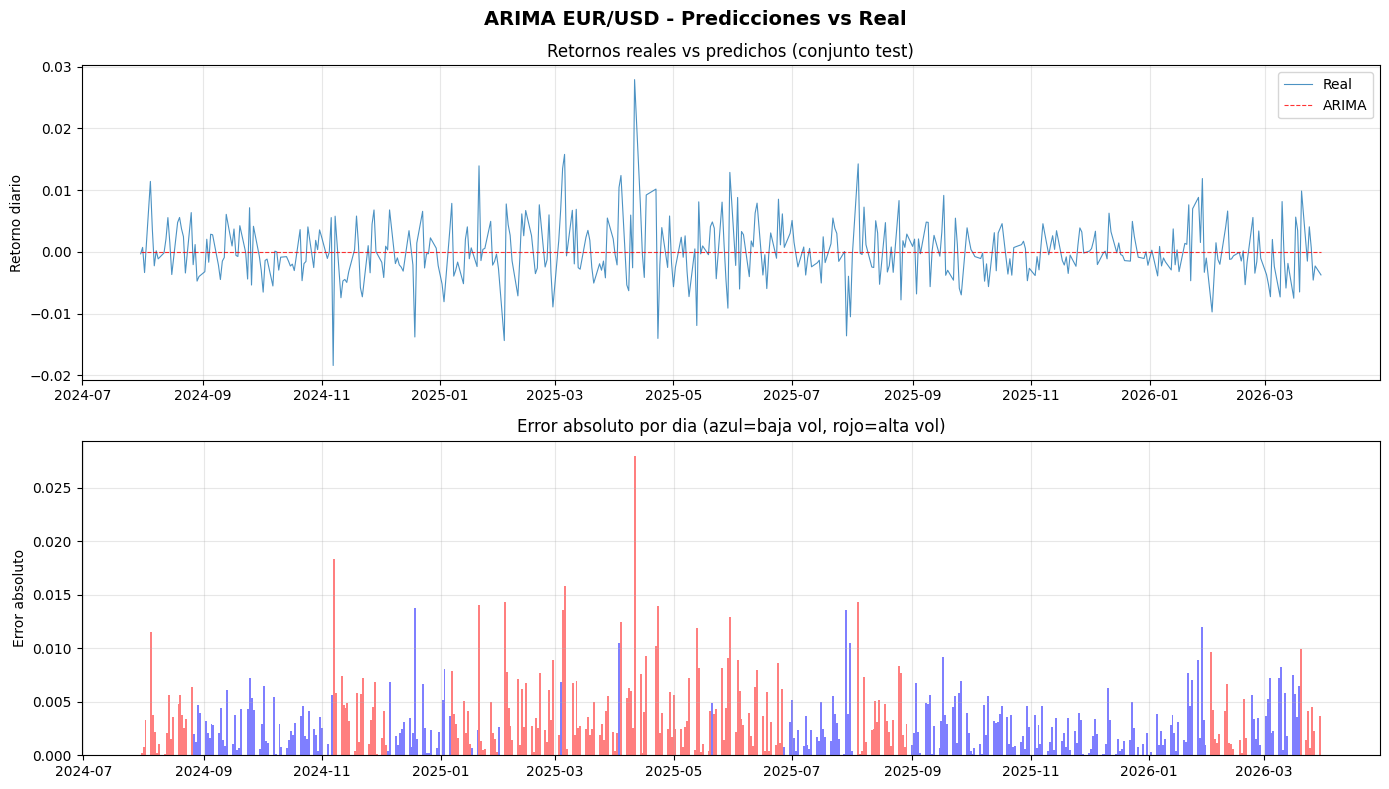

Gráfico guardado en la carpeta results


In [6]:
# Visualización predicciones vs real EUR/USD
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("ARIMA EUR/USD - Predicciones vs Real", fontsize=14, fontweight="bold")

# Gráfico superior: serie completa
axes[0].plot(test.index, test.values, color="#1f77b4", linewidth=0.8, label="Real", alpha=0.8)
axes[0].plot(test.index, predicciones.values, color="red", linewidth=0.8, label="ARIMA", alpha=0.8, linestyle="--")
axes[0].set_title("Retornos reales vs predichos (conjunto test)")
axes[0].set_ylabel("Retorno diario")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico inferior: errores por régimen
errores = np.abs(test.values - predicciones.values)
colores_regimen = ["blue" if r == "Baja" else "red" for r in regimen_test_alineado.values]
axes[1].bar(test.index, errores, color=colores_regimen, alpha=0.5, width=1)
axes[1].set_title("Error absoluto por dia (azul=baja vol, rojo=alta vol)")
axes[1].set_ylabel("Error absoluto")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/03_arima_eurusd.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en la carpeta results")

## Análisis visual de predicciones y errores (ARIMA en EUR/USD)
+ **Predicción estática (Gráfico superior):** La serie proyectada por ARIMA se muestra como una línea completamente plana en el nivel cero. Esto confirma de forma visual el diagnóstico del modelo (0,0,0): al no detectar patrones históricos, carece por completo de capacidad para anticipar la dirección o magnitud de los movimientos del mercado.

+ **Distribución del error por régimen (Gráfico inferior):** Los errores absolutos durante los periodos de alta volatilidad (barras rojas)son sistemáticamente superiores a los del régimen estable (barras azules). La concentración de los picos de error más extremos en las fases turbulentas evidencia la vulnerabilidad e ineficiencia de los modelos lineales ante shocks de inestabilidad en el mercado.

# ARIMA A LOS 5 ACTIVOS

In [7]:
# ARIMA sobre los 5 activos - bucle completo
resultados_arima = []
ordenes_optimos = {}

for activo in activos:
    print(f"\nProcesando {activo.upper()}...")
    
    retornos = datos[activo]["Retorno"].dropna()
    regimen = datos[activo]["Regimen"].dropna()
    
    # Split 80/20
    split = int(len(retornos) * 0.8)
    train = retornos.iloc[:split]
    test = retornos.iloc[split:]
    regimen_test = regimen.iloc[split:].reindex(test.index)
    
    # Grid search
    mejor_aic = np.inf
    mejor_orden = (0, 0, 0)
    for p, q in product(range(4), range(4)):
        try:
            m = ARIMA(train, order=(p, 0, q)).fit()
            if m.aic < mejor_aic:
                mejor_aic = m.aic
                mejor_orden = (p, 0, q)
        except:
            continue

    ordenes_optimos[activo] = mejor_orden

    # Entrenar y predecir
    ajuste = ARIMA(train, order=mejor_orden).fit()
    predicciones = ajuste.forecast(steps=len(test))
    predicciones.index = test.index

    # Métricas globales
    mae = mean_absolute_error(test, predicciones)
    rmse = np.sqrt(mean_squared_error(test, predicciones))

    resultados_arima.append({
        "Activo": activo.upper(),
        "Orden": str(mejor_orden),
        "AIC": round(mejor_aic, 2),
        "MAE_global": round(mae, 6),
        "RMSE_global": round(rmse, 6),
        "MAE_baja_vol": None,
        "MAE_alta_vol": None,
    })

    # Métricas por régimen
    for reg_val, reg_nombre in [("Baja", "baja_vol"), ("Alta", "alta_vol")]:
        mask = regimen_test == reg_val
        if mask.sum() > 0:
            mae_r = mean_absolute_error(test[mask], predicciones[mask])
            resultados_arima[-1][f"MAE_{reg_nombre}"] = round(mae_r, 6)

    print(f" Orden: {mejor_orden} | MAE: {mae:.6f} | MAE baja: {resultados_arima[-1]['MAE_baja_vol']} | MAE alta: {resultados_arima[-1]['MAE_alta_vol']}")

# Tabla resumen
df_arima  = pd.DataFrame(resultados_arima)
print("\n\nRESUMEN ARIMA - TODOS LOS ACTIVOS")
print("=" * 80)
print(df_arima.to_string(index=False))

# Guardar
df_arima.to_csv("../results/arima_resultados.csv", index=False)
print("\nGuardado en results/arima_resultados.csv")


Procesando EURUSD...
 Orden: (0, 0, 0) | MAE: 0.003498 | MAE baja: 0.002893 | MAE alta: 0.004317

Procesando GBPUSD...
 Orden: (0, 0, 0) | MAE: 0.003611 | MAE baja: 0.003398 | MAE alta: 0.004707

Procesando USDJPY...
 Orden: (0, 0, 0) | MAE: 0.004947 | MAE baja: 0.003737 | MAE alta: 0.005722

Procesando BTC...
 Orden: (0, 0, 2) | MAE: 0.017434 | MAE baja: 0.015968 | MAE alta: 0.029341

Procesando ETH...
 Orden: (2, 0, 1) | MAE: 0.026968 | MAE baja: 0.025195 | MAE alta: 0.034948


RESUMEN ARIMA - TODOS LOS ACTIVOS
Activo     Orden       AIC  MAE_global  RMSE_global  MAE_baja_vol  MAE_alta_vol
EURUSD (0, 0, 0) -13689.58    0.003498     0.004766      0.002893      0.004317
GBPUSD (0, 0, 0) -12872.38    0.003611     0.004648      0.003398      0.004707
USDJPY (0, 0, 0) -13158.00    0.004947     0.006460      0.003737      0.005722
   BTC (0, 0, 2)  -9217.53    0.017434     0.024789      0.015968      0.029341
   ETH (2, 0, 1)  -8034.85    0.026968     0.038489      0.025195      0.034948


##Conclusiones globales del modelo ARIMA

- **Forex:** El MAE global oscila entre 0.0035 y 0.0049. Estas magnitudes tan reducidas reflejan unos retornos diarios que orbitan muy cerca de cero. La obtención sistemática de un orden (0,0,0) para los tres pares confirma empíricamente la ausencia de cualquier estructura temporal lineal explotable, comportándose como ruido blanco puro.
- **Criptomonedas:** El margen de error multiplica entre 5-8 veces al del mercado de divisas (BTC:  0.0174, ETH: 0.0270). A diferencia de Forex, BTC y ETH sí presentan cierta estructura temporal - con órdenes óptimos de (0,0,2) y (2,0,1) respectivamente -, lo que indica la existencia de una dependencia temporal lineal débil que el algoritmo es capaz de detectar. 

- **Impacto de la volatilidad:** Se constata un patrón universal en los cinco activos: el error predictivo (MAE) durante los regímenes de alta volatilidad supera sistemáticamente al de los periodos de baja volatilidad. Esta degradación del rendimiento bajo estrés de mercado justifica de forma concluyente la necesidad de evaluar los modelos posteriores segmentando por régimen.